### **LIVRABLE 1: Préparation des données**
**GROUPE 2:**

Séréna DAGHA

Jennifer Ouédraogo

Alex KINDA

Ghislain BOGNIN


### **Importation de la bibliothèque d'analyse de données principale**


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### **Chargement des données et affichage d'aperçu**

In [ ]:

# Chargement du dataset depuis le fichier CSV
data = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

# Affichage des 5 premières lignes pour s'assurer que le chargement s'est bien passé
print("--- Aperçu des 5 premières et 5 dernières lignes du dataset ---")
display(data)

--- Aperçu des 5 premières et 5 dernières lignes du dataset ---


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


### **Informations globales sur le dataset**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

Les informations sur notre dataset nous montrent que toutes nos variables sont flottantes. Cependant certaines d'entre elles sont des fausses flottantes comme **Diabetes_binary** qui est sous forme binaire mais en réalité est catégorielle pour **OUI** et **NON**.
Nous avons **HighBP** qui donne une mésure à partir d'une échelle et bien d'autres variables. Afin d'éviter de les confondre en des fausses variables numériques dans notre analyse descriptive, nous allons les séparer.  

Cependant notre variable Age dont les valeurs vont de **1 à 13** ne sont pas réellement des numériques car ces chiffres représentent des **tranches d'âges**. On pourrait changer le type de cette variable en catégorie mais cela nous causera des problèmes dans la suite du travail avec l'encodage car cela reviendra à créer une variable représentant chaque classe; on se retrouverait avec de **multiples variables**.

Pour palier à ce problème nous allons définir chaque tranche d'âge des différentes classes sur lesquelles nous allons appliquer **la médiane**. Cette méthode nous permettra de représenter chaque individu par la médiane de sa classe et ainsi garder le type float de la variable **Age**.

### **Statistiques descriptives**

**Tranches d'âge définies :**
1 : 18-24ans
2 : 25-29ans
3 : 30-34ans
4 : 35-39ans
5 : 40-44ans
6 : 45-49ans
7 : 50-54ans
8 : 55-59ans
9 : 60-64ans
10 : 65-69ans
11 : 70-74ans
12 : 75-79ans
13 : 80ans et +

Cependant pour tranche d'âge de 80 et plus nous allons fixer notre médiane à 82.

In [ ]:
# 1. Définition et application du dictionnaire pour la variable Age
age_mapping = {
    1.0: 21,
    2.0: 27,
    3.0: 32,
    4.0: 37,
    5.0: 42,
    6.0: 47,
    7.0: 52,
    8.0: 57,
    9.0: 62,
    10.0: 67,
    11.0: 72,
    12.0: 77,
    13.0: 82
}

# Remplacement des catégories par l'âge médian estimé
data['Age'] = data['Age'].map(age_mapping)

print("Conversion de l'âge terminée.\n")


# 2. Séparation des vraies variables numériques des fausses
categorical_cols = [
    'Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'Smoker',
    'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk',
    'Sex', 'Education', 'Income', 'GenHlth'
]

numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age']


# 3. Conversion des colonnes catégorielles dans le bon type Pandas ('category')
data[categorical_cols] = data[categorical_cols].astype('category')


# 4. Statistiques descriptives des variables numériques
print("--- Statistiques des variables NUMÉRIQUES ---")
display(data[numerical_cols].describe().round(2))

Conversion de l'âge terminée.

--- Statistiques des variables NUMÉRIQUES ---


,BMI,MentHlth,PhysHlth,Age
count,253680.00,253680.00,253680.00,253680.00
mean,28.38,3.18,4.24,57.14
std,6.61,7.41,8.72,15.32
min,12.00,0.00,0.00,21.00
25%,24.00,0.00,0.00,47.00
50%,27.00,0.00,0.00,57.00
75%,31.00,2.00,3.00,67.00
max,98.00,30.00,30.00,82.00


En observant ces statistiques, on remarque un grand écart entre les valeurs maximales et les quartiles 3 de nos variables quantitatives. Ce grand décalage s'explique par la présence de valeurs abérantes.Ces outliers peuvent être resolus en utilisant une méthode robuste comme robusscaler dans la standardisation des données.

### **Statistiques descriptives des variables catégorielles**

In [ ]:
data.describe(include='category')

,Diabetes_binary,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,DiffWalk,Sex,Education,Income
count,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0,253680.0
unique,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5.0,2.0,2.0,6.0,8.0
top,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,6.0,8.0
freq,218334.0,144851.0,146089.0,244210.0,141257.0,243388.0,229787.0,191920.0,160898.0,205841.0,239424.0,241263.0,232326.0,89084.0,211005.0,141974.0,107325.0,90385.0


Nous pouvons voir à partir de ce tableau, les classes majoritaires de nos différentes variables qualitatives. Nous pouvons dès à présent affirmer que notre variable cible est déséquilibrée, ainsi que les autres variables.

### **Identification des valeurs manquantes et gestion des doublons**

Les statistiques descriptives affichées plus haut nous permettaient de savoir que nos variables ne contiennent aucune valeur manquante; cependant afin de vérifier ces informations, nous allons calculer le nombre de valeurs manquantes ainsi que celui des doublons afin d'éviter la redondance.

In [ ]:
print("--- 1. Recherche des valeurs manquantes ---")
# Calcul du nombre et du pourcentage de valeurs manquantes par colonne
valeurs_manquantes = data.isnull().sum()
pourcentage_manquantes = (valeurs_manquantes / len(data)) * 100

missing_data = pd.DataFrame({
    'Valeurs Manquantes': valeurs_manquantes,
    'Pourcentage (%)': pourcentage_manquantes.round(2)
})

# On n'affiche que les colonnes qui ont des valeurs manquantes
colonnes_avec_nan = missing_data[missing_data['Valeurs Manquantes'] > 0]
if colonnes_avec_nan.empty:
    print("Aucune valeur manquante détectée dans le dataset ")
else:
    display(colonnes_avec_nan)

import pandas as pd

print("--- AUDIT DES DOUBLONS ---")

# 1. Compter le nombre exact de doublons
nb_doublons = data.duplicated().sum()
print(f"Nombre de lignes considérées comme doublons exacts : {nb_doublons}")
print(f"Cela représente {(nb_doublons / len(data)) * 100:.2f}% du jeu de données.\n")

# 2. Extraire TOUTES les lignes impliquées (Originaux + Copies)
# keep=False permet de garder toutes les versions d'une même ligne
tous_les_doublons = data[data.duplicated(keep=False)]

# 3. Trier les données pour mettre les profils identiques les uns sous les autres
# On trie par toutes les colonnes pour que les "clones" soient adjacents
doublons_tries = tous_les_doublons.sort_values(by=list(data.columns))

# 4. Affichage des 10 premières lignes pour inspection visuelle
print("Echantillon des profils parfaitement identiques :")
display(doublons_tries.head(5))

if nb_doublons > 0:
    # Suppression des doublons tout en gardant la première occurrence
    data_cleaned = data.drop_duplicates(keep='first')
    print("Les doublons ont été supprimés.")
    print(f"Nouvelle taille du dataset : {data_cleaned.shape}")

--- 1. Recherche des valeurs manquantes ---
Aucune valeur manquante détectée dans le dataset 
--- AUDIT DES DOUBLONS ---
Nombre de lignes considérées comme doublons exacts : 24206
Cela représente 9.54% du jeu de données.

Echantillon des profils parfaitement identiques :


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,57,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,57,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,67,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,67,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,37,6.0,8.0


Les doublons ont été supprimés.
Nouvelle taille du dataset : (229474, 22)


### **Analyse univariée**

##### - **Pour les variables qualitatives**

--- Analyse univariée des variables catégorielles ---


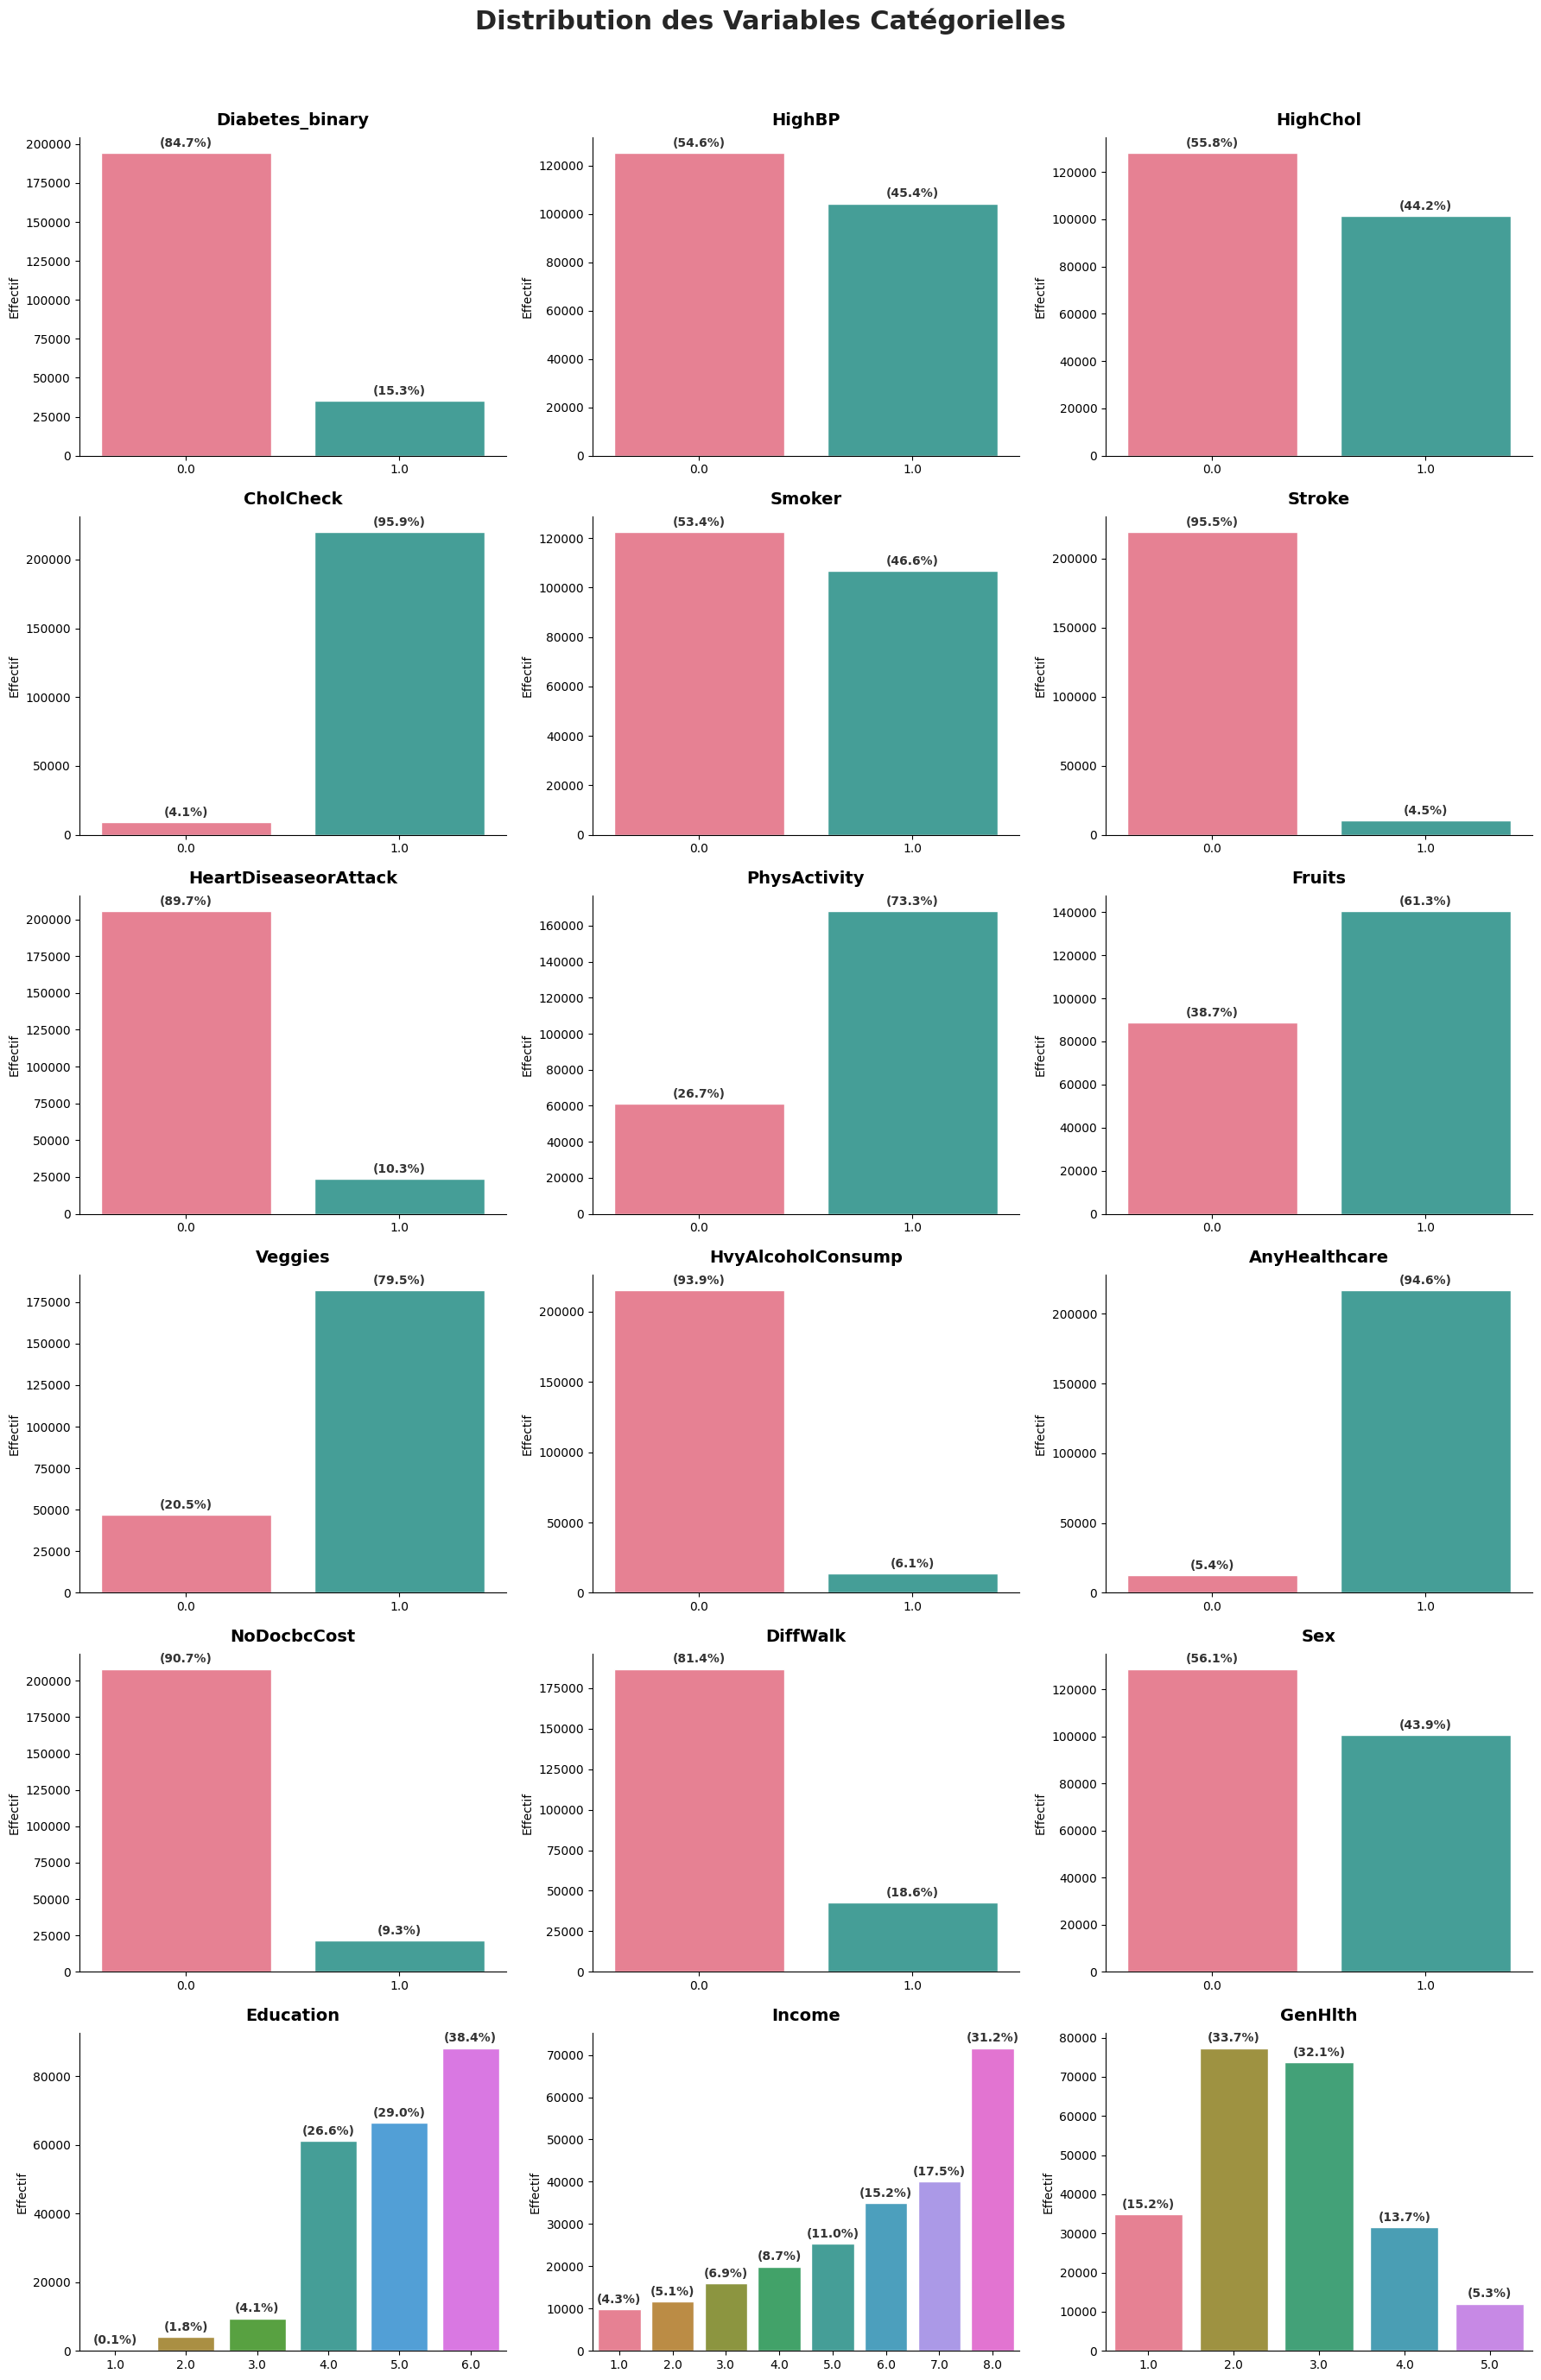

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

print("--- Analyse univariée des variables catégorielles ---")

# Calcul dynamique de la grille
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

sns.set_theme(style="whitegrid")

for i, col in enumerate(categorical_cols):
    ax = axes[i]

    sns.countplot(
        data=data_cleaned,
        x=col,
        ax=ax,
        palette='husl', # Couleurs très variées, vives et harmonieuses
        hue=col,
        legend=False
    )

    # Calcul du total des répondants
    total = len(data_cleaned[col].dropna())

    # Ajout du compte ET du pourcentage
    for container in ax.containers:
        labels = [f'({(v.get_height()/total)*100:.1f}%)' for v in container]
        ax.bar_label(container, labels=labels, padding=3, fontweight='bold', color='#333333', size=10)

    # Esthétique
    ax.set_title(f'{col}', fontweight='bold', fontsize=14, pad=10)
    ax.set_ylabel('Effectif')
    ax.set_xlabel('')
    sns.despine(ax=ax)

# Nettoyage des cadres vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution des Variables Catégorielles", fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Cet aperçu visuel vient confirmer nos dirs plus haut: nous avons des classes déséquilibrées ce qui signifiie que les distributions ne sont pas gaussiennes.

##### **- Pour les variables quantitatives**

Génération des graphiques univariés en cours...


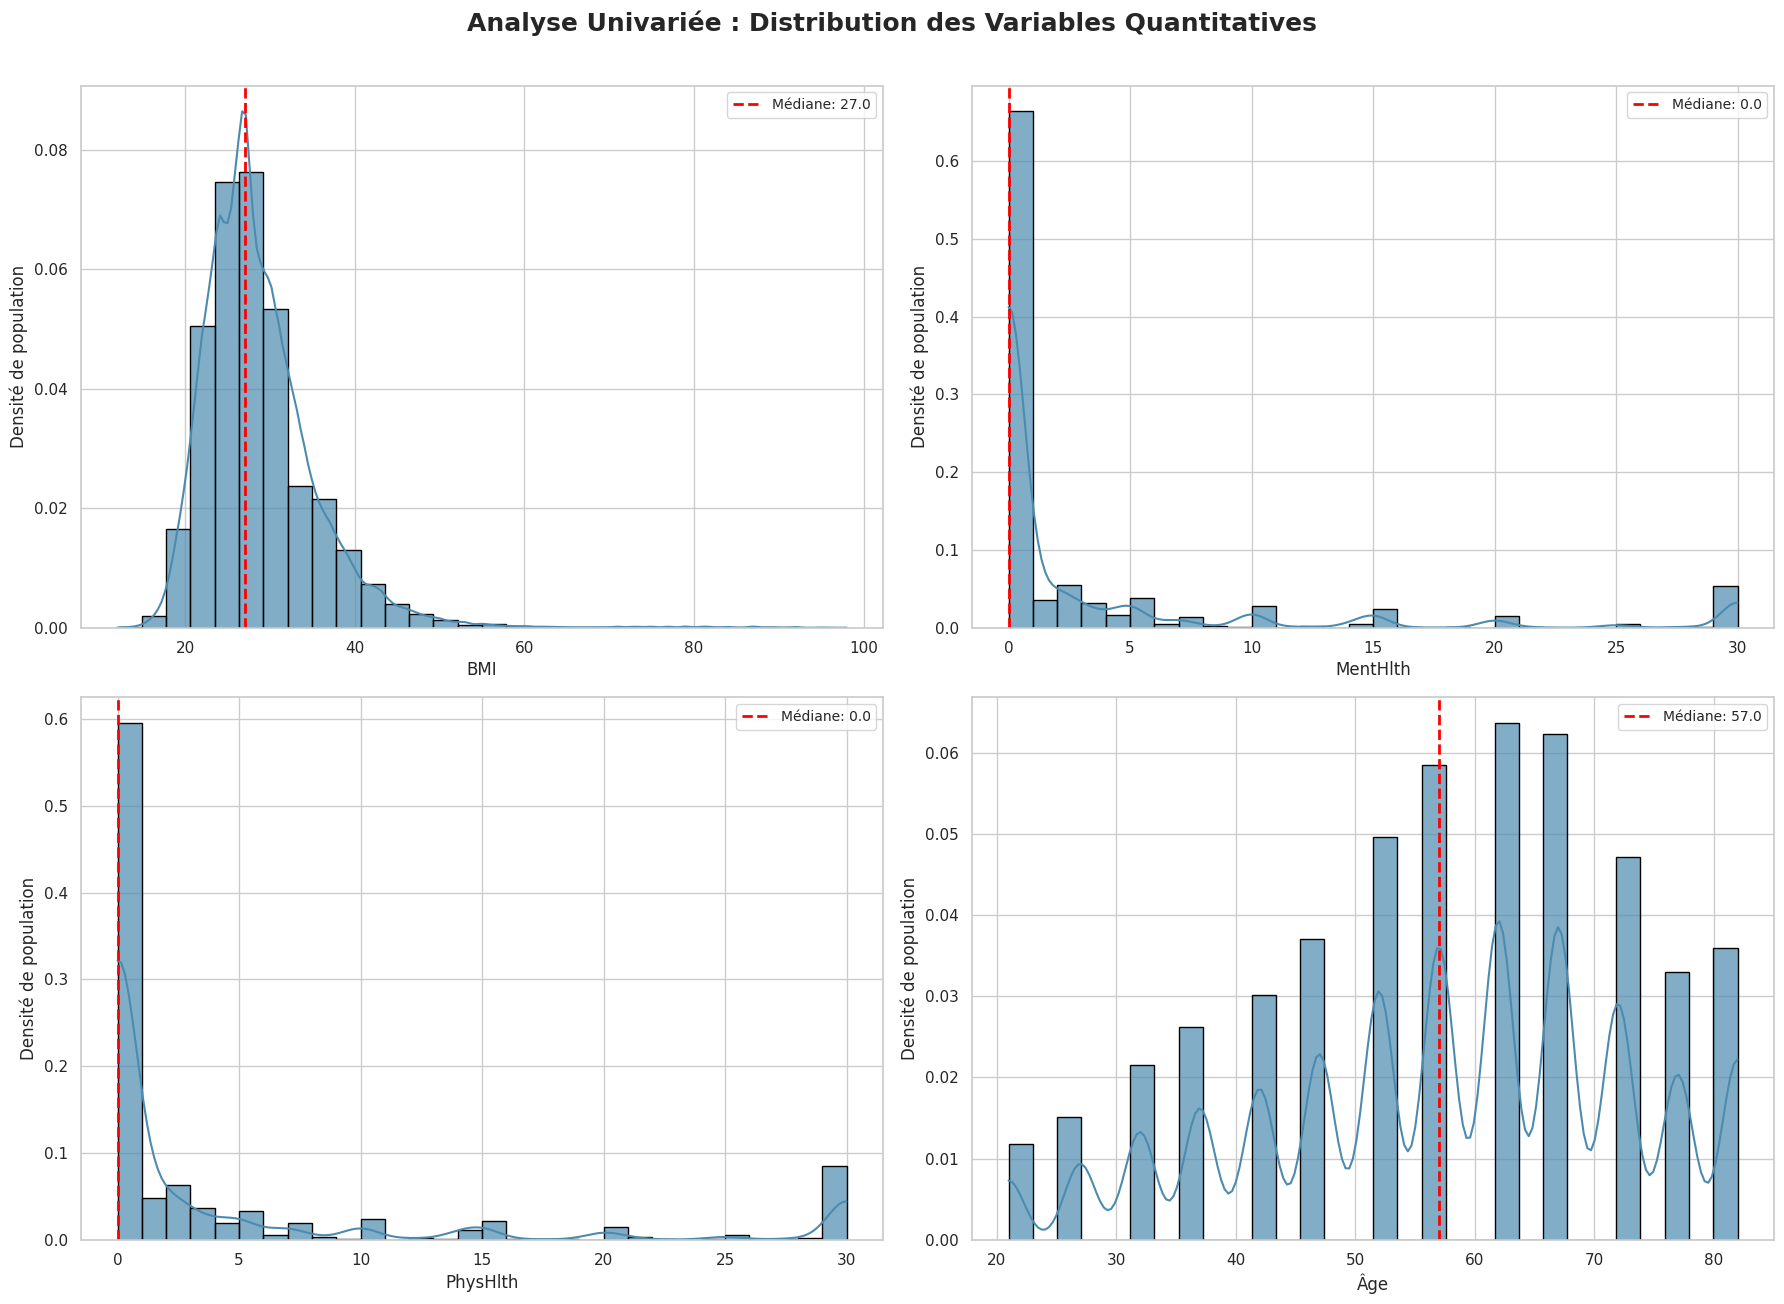

([<matplotlib.axis.XTick at 0x7a97b492b140>,
 [Text(0, 0, 'BMI'),
  Text(1, 0, 'MentHlth'),
  Text(2, 0, 'PhysHlth'),
  Text(3, 0, 'Âge')])

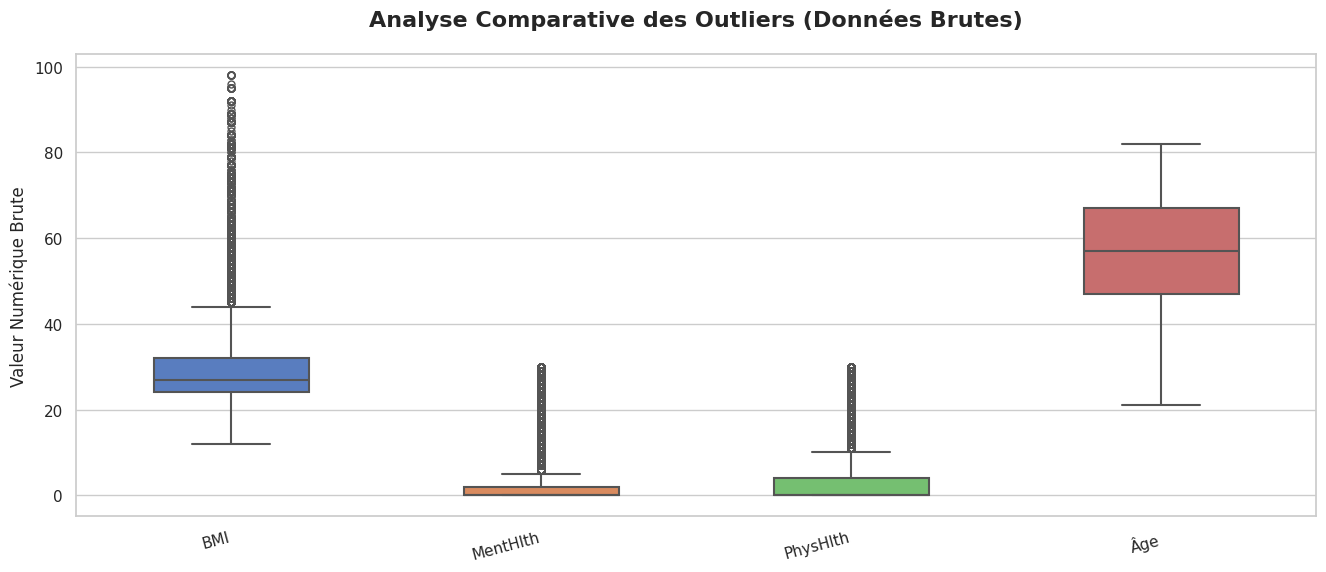

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Configuration globale pour de beaux graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12) # Taille par défaut assez grande
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.weight'] = 'normal'

# Création d'une figure avec des sous-graphiques (2 lignes, 2 colonnes)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Pour simplifier la boucle, on aplatit la matrice des axes (2,2) en un vecteur (4)
axes_flat = axes.flatten()

# Dictionnaire pour personnaliser les titres et labels
label_mapping = {
    'Age': ('Âge', ''),
    'BMI': ('BMI', ''),
    'MentHlth': ('MentHlth', ''),
    'PhysHlth': ('PhysHlth', '')
}

print("Génération des graphiques univariés en cours...")

for i, var in enumerate(numerical_cols):
    ax = axes_flat[i]

    # 1. Histogramme avec courbe de densité (KDE)
    sns.histplot(
        data=data_cleaned,
        x=var,
        kde=True,
        ax=ax,
        color="#4C8BB0", # Bleu Seaborn standard
        edgecolor='black',
        alpha=0.7,
        bins=30, # Ajuste le nombre de barres
        stat='density' # Affiche la densité plutôt que le comptage brut
    )

    # Personnalisation des axes et titre
    x_label, title = label_mapping.get(var, (var, var))
    ax.set_title(title, pad=15)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Densité de population")

    # Ajout d'une ligne pour la médiane (plus robuste que la moyenne)
    mediane = data_cleaned[var].median()
    ax.axvline(mediane, color='red', linestyle='--', linewidth=2, label=f'Médiane: {mediane:.1f}')
    ax.legend(loc='upper right', fontsize=10)

# Titre général de la figure
plt.suptitle("Analyse Univariée : Distribution des Variables Quantitatives", fontsize=18, fontweight='bold', y=0.96)

# Ajustement automatique des marges pour éviter les chevauchements
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Cellule suivante : Les Boxplots pour l'analyse précise des outliers ---
plt.figure(figsize=(16, 6))

# Création d'un seul graphique regroupant les 4 variables
sns.boxplot(
    data=data_cleaned[numerical_cols],
    palette='muted',
    width=0.5,
    orient='v', # Boxplots verticaux
    fliersize=5, # Taille des points d'outliers
    linewidth=1.5
)

plt.title("Analyse Comparative des Outliers (Données Brutes)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Valeur Numérique Brute")
plt.xticks(
    range(4),
    [label_mapping[v][0] for v in numerical_cols],
    rotation=15, ha='right', fontsize=11
)

Toutes ces visualisations attestent la présence d'outliers dans nos variables d'où leur distribution non gaussiène.

### **Analyse bivariée**

--- Analyse Bivariée: Évaluation du Risque de Diabète ---


/tmp/ipykernel_7711/1105845360.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_taux = data_cleaned_copie.groupby(col)[cible].mean().reset_index()
/tmp/ipykernel_7711/1105845360.py:45: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(
/tmp/ipykernel_7711/1105845360.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_taux = data_cleaned_copie.groupby(col)[cible].mean().reset_index()
/tmp/ipykernel_7711/1105845360.py:45: UserWarning: Numpy array is not a supported type for `palette`. Please convert 

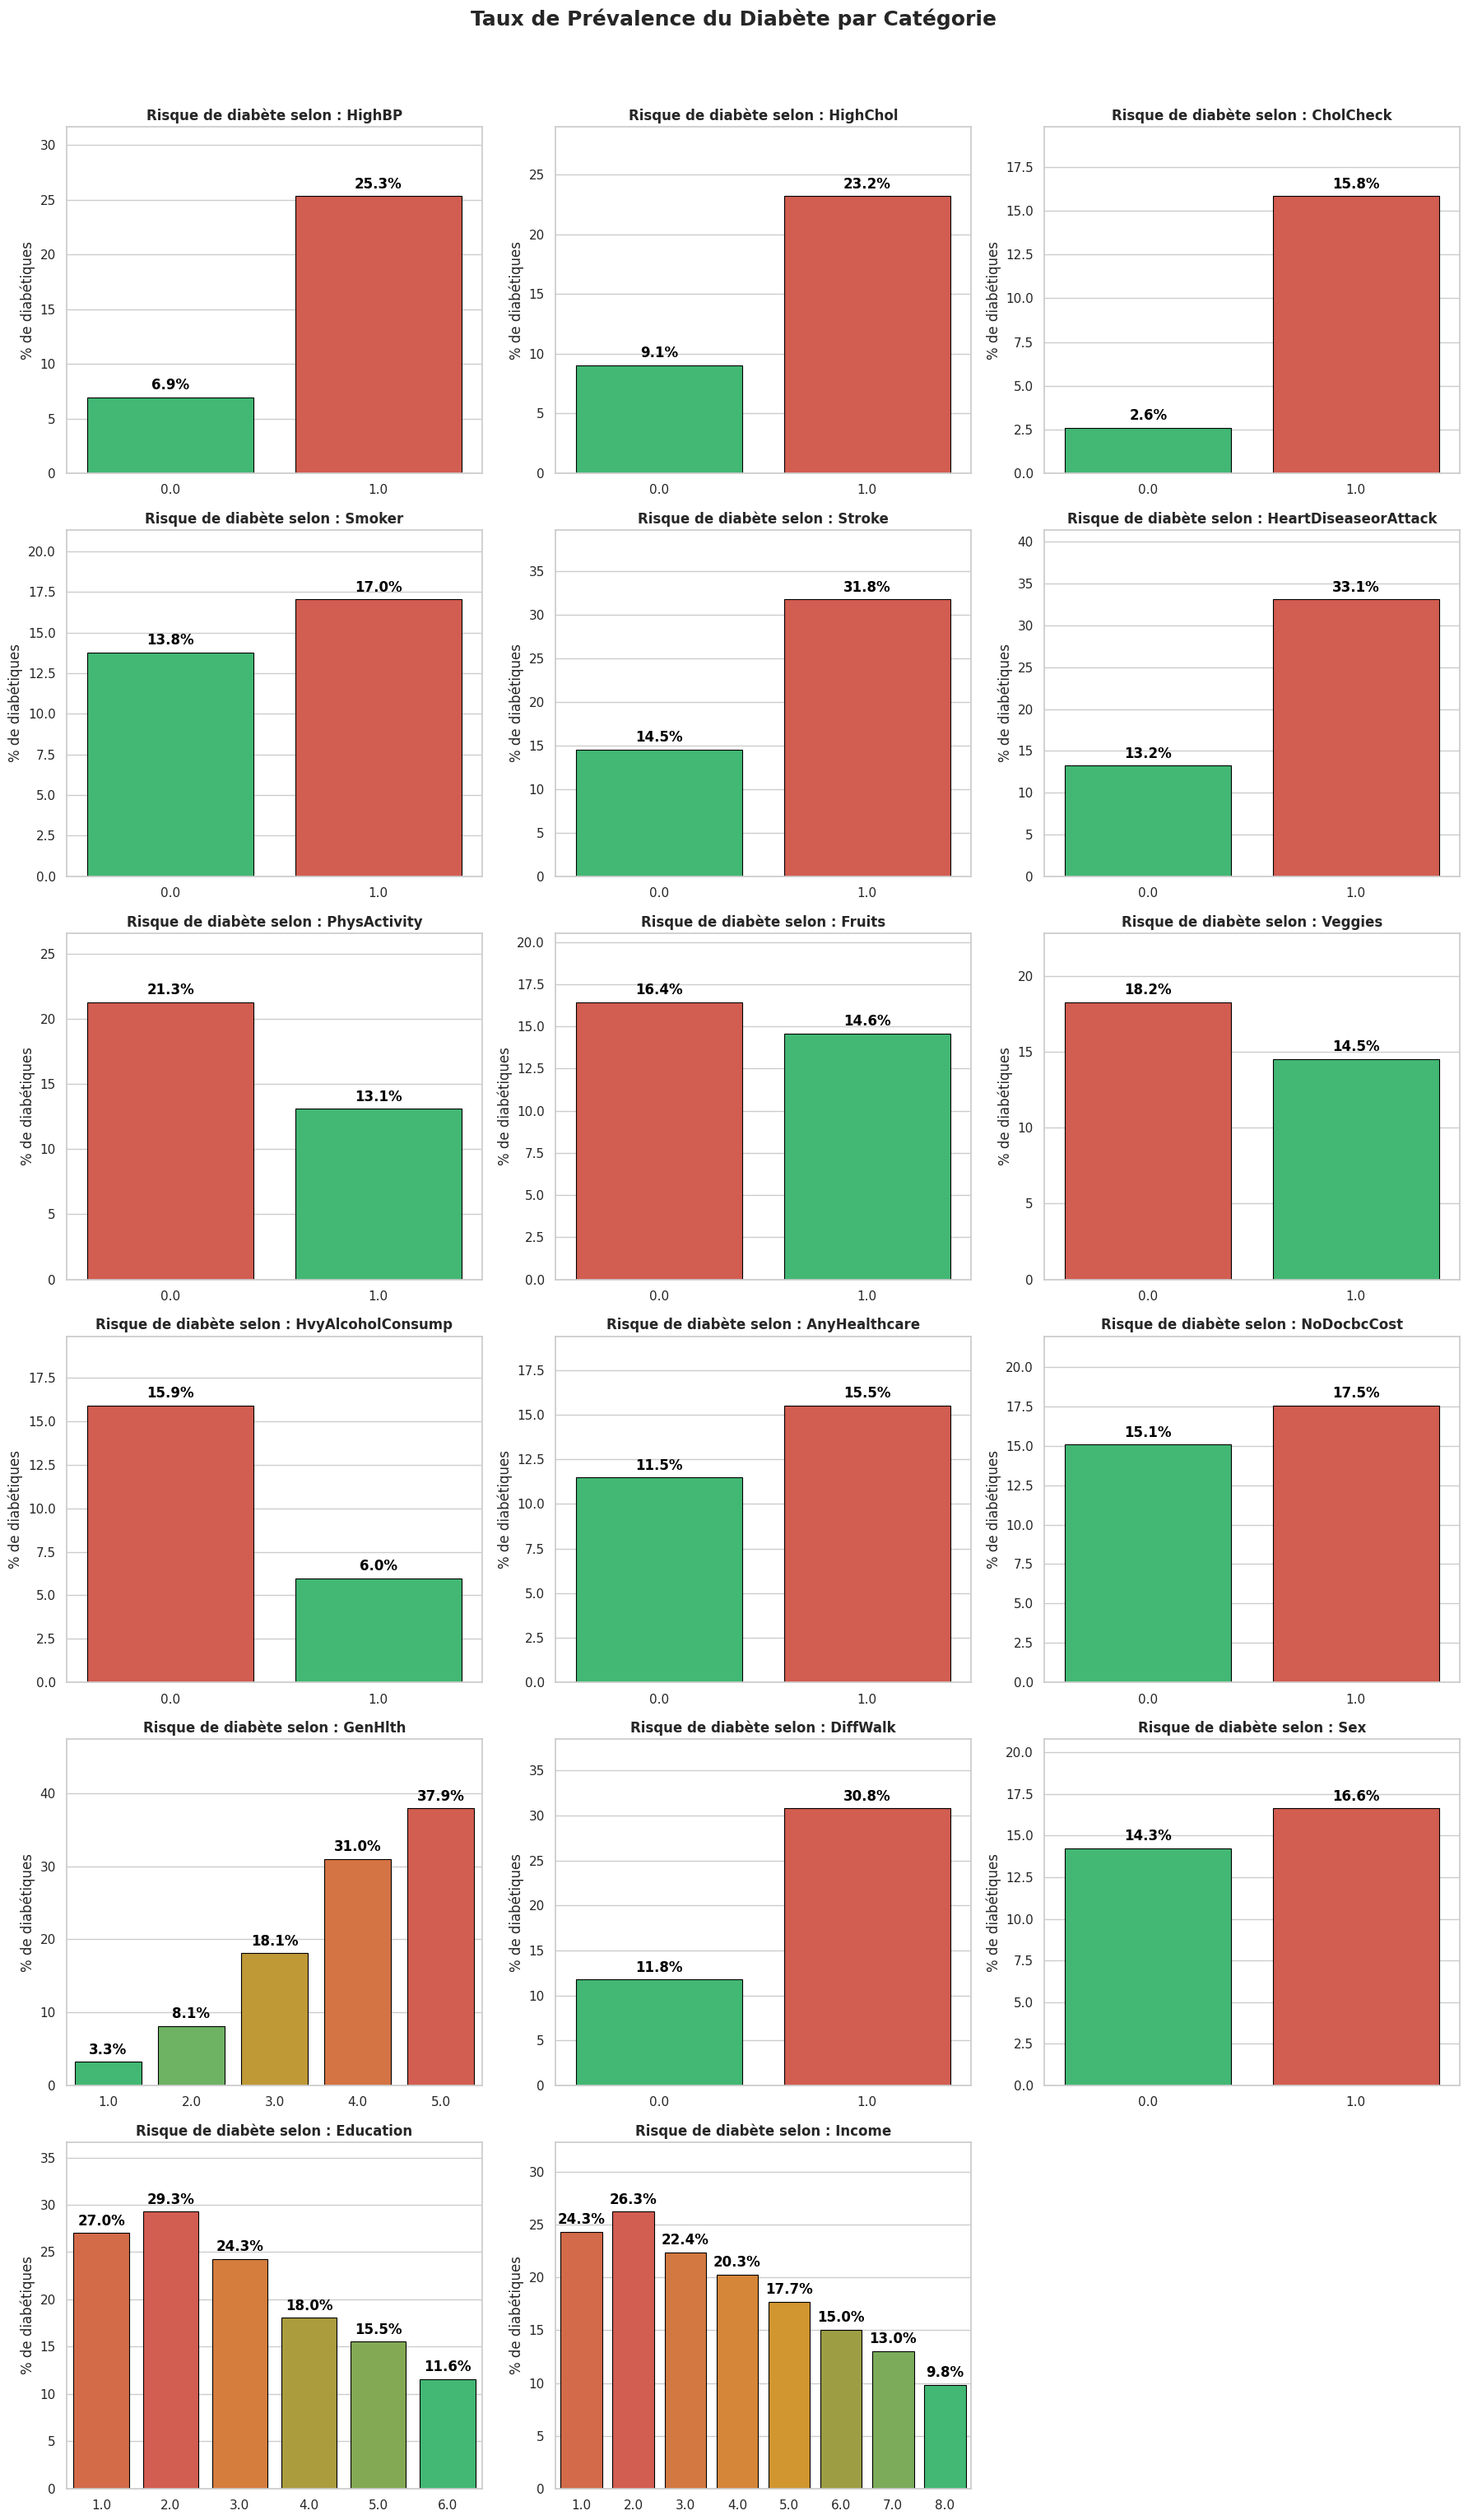


--- Analyse Bivariée des variables continues ---


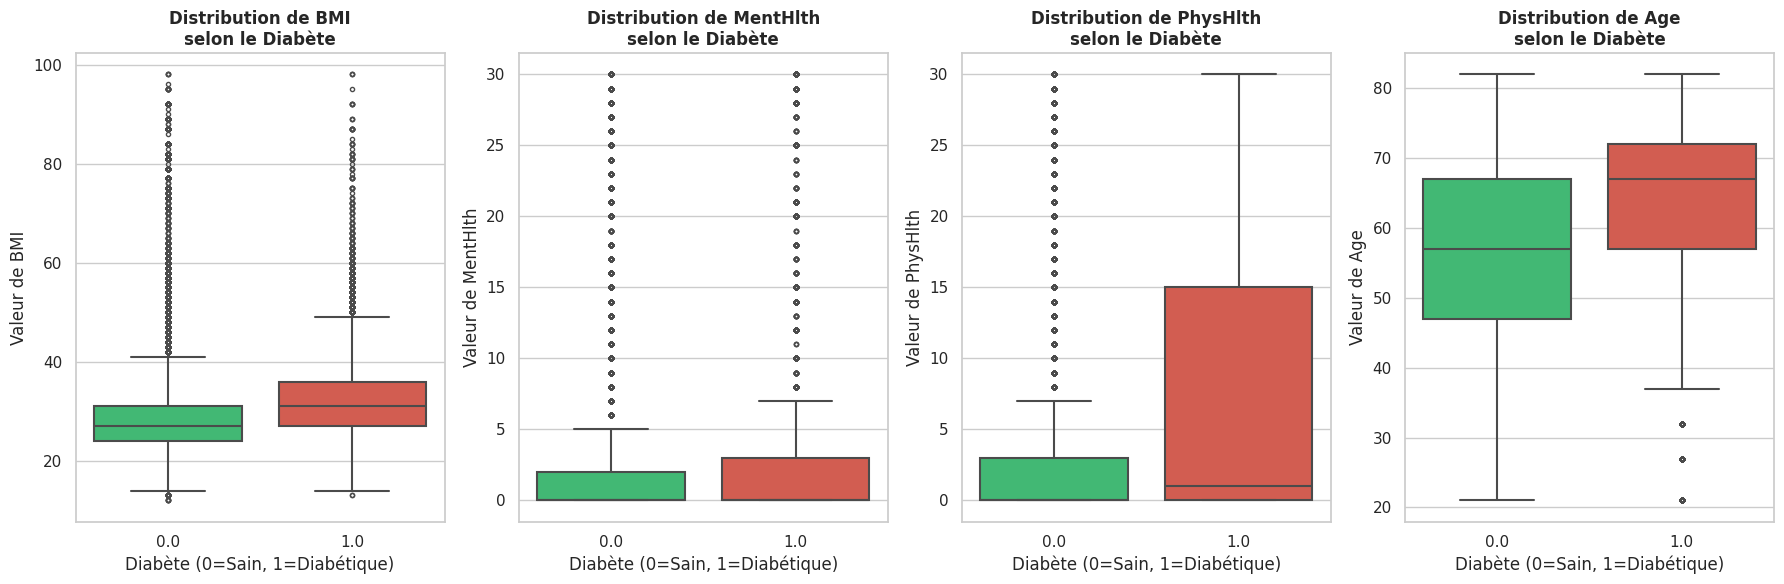

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

print("--- Analyse Bivariée: Évaluation du Risque de Diabète ---")

# 1. Configuration initiale
sns.set_theme(style="whitegrid")
cible = 'Diabetes_binary'

# AJOUT : On s'assure que 'Age' est bien traitée comme une variable continue si tu l'as convertie
vraies_continues = ['BMI', 'MentHlth', 'PhysHlth', 'Age']

# On liste les catégorielles en excluant la cible et les continues
categorielles = [col for col in data_cleaned.columns if col not in vraies_continues and col != cible]

# Création du dégradé de risque (Vert -> Orange -> Rouge)
cmap_risque = LinearSegmentedColormap.from_list("RiskLevel", ['#2ecc71', '#f39c12', '#e74c3c'])

data_cleaned_copie = data_cleaned.copy()
# On convertit la cible en numérique UNIQUEMENT dans cette copie
data_cleaned_copie[cible] = data_cleaned_copie[cible].astype(float)

# =====================================================================
# PARTIE A : Variables Catégorielles vs Cible (Taux de risque)
# =====================================================================
ncols_cat = 3
nrows_cat = math.ceil(len(categorielles) / ncols_cat)
fig_cat, axes_cat = plt.subplots(nrows=nrows_cat, ncols=ncols_cat, figsize=(18, 5 * nrows_cat))
axes_cat = axes_cat.flatten()

for i, col in enumerate(categorielles):

    # Calcul du pourcentage de malades par catégorie
    df_taux = data_cleaned_copie.groupby(col)[cible].mean().reset_index()
    df_taux['Taux_Diabete_Pourcent'] = df_taux[cible] * 100

    # Application du dégradé basé sur la valeur du pourcentage
    norm = plt.Normalize(df_taux['Taux_Diabete_Pourcent'].min(), df_taux['Taux_Diabete_Pourcent'].max())
    couleurs_dynamiques = cmap_risque(norm(df_taux['Taux_Diabete_Pourcent'].values))

    sns.barplot(
        data=df_taux,
        x=col,
        y='Taux_Diabete_Pourcent',
        ax=axes_cat[i],
        palette=couleurs_dynamiques,
        hue=col,
        legend=False,
        edgecolor='black',
        linewidth=0.8
    )

    # Ajout du pourcentage exact au-dessus de chaque barre
    for container in axes_cat[i].containers:
        axes_cat[i].bar_label(container, fmt='%.1f%%', padding=4, fontweight='bold', color='black')

    axes_cat[i].set_title(f'Risque de diabète selon : {col}', fontweight='bold', fontsize=12)
    axes_cat[i].set_ylabel('% de diabétiques')
    axes_cat[i].set_xlabel('')
    axes_cat[i].set_ylim(0, df_taux['Taux_Diabete_Pourcent'].max() * 1.25)

for j in range(i + 1, len(axes_cat)):
    fig_cat.delaxes(axes_cat[j])

# Titre global
plt.suptitle("Taux de Prévalence du Diabète par Catégorie", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# PARTIE B : Variables Continues vs Cible (Boîtes à moustaches)
# =====================================================================
print("\n--- Analyse Bivariée des variables continues ---")

fig_num, axes_num = plt.subplots(nrows=1, ncols=len(vraies_continues), figsize=(18, 6))
couleurs_diabete = {0.0: '#2ecc71', 1.0: '#e74c3c'}

for i, col in enumerate(vraies_continues):
    sns.boxplot(
        data=data_cleaned_copie,
        x=cible,
        y=col,
        ax=axes_num[i],
        palette=couleurs_diabete,
        hue=cible,
        legend=False,
        linewidth=1.5,
        fliersize=3
    )

    axes_num[i].set_title(f'Distribution de {col}\nselon le Diabète', fontweight='bold')
    axes_num[i].set_xlabel('Diabète (0=Sain, 1=Diabétique)')
    axes_num[i].set_ylabel(f'Valeur de {col}')

plt.tight_layout()
plt.show()


L’analyse met en évidence que le diabète est principalement associé à l’**âge** avancé et à l’**obésité**. Les individus diabétiques sont en moyenne plus âgés et présentent un indice de masse corporelle (BMI) plus élevé, souvent situé dans la catégorie de l’obésité. Par ailleurs, leur santé physique est nettement plus dégradée, contrairement à la santé mentale qui varie peu entre les groupes.

Un gradient socio-économique est aussi observé : les individus ayant un **faible niveau de revenu ou d’éducation** présentent un risque plus élevé. De plus, la santé perçue constitue un indicateur particulièrement pertinent, le risque de diabète augmentant fortement lorsque celle-ci se dégrade.

Enfin, l’association apparente entre forte consommation d’alcool et faible prévalence du diabète est observée suscitant des questionnements.


Avant de supprimer ou de créer d'autres variables, nous allons vérifer la relation multiples entre nos variables déjà existantes.

**Dans un premier temps nous allons étudier les multiples relations entre les variables numériques puis dans un second temps, les variables catégorielles.**

### **Analyse multivariée: Analyse des Composants Multiples**

--- Matrice de Corrélation de Pearson (Variables Continues) ---


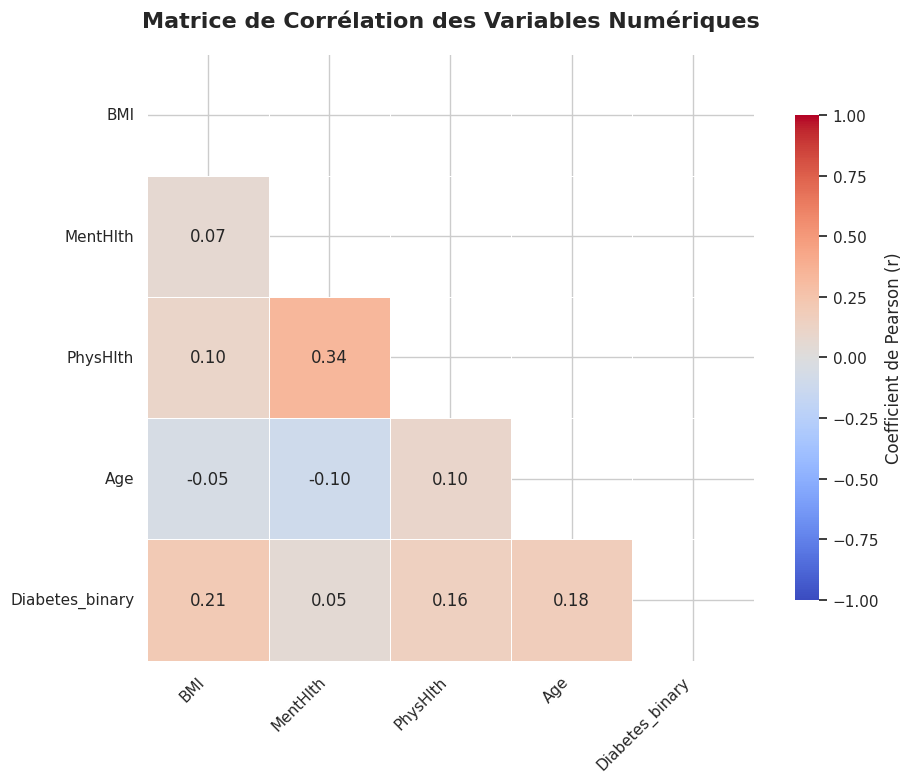

In [ ]:

print("--- Matrice de Corrélation de Pearson (Variables Continues) ---")

# On s'assure d'avoir la bonne liste
cible = 'Diabetes_binary'

# On réunit les continues et la cible pour la matrice
colonnes_corr = numerical_cols + [cible]

# 1. Calcul de la matrice de corrélation (Pearson par défaut)
matrice_corr2 = data_cleaned_copie[colonnes_corr].corr()

# 2. Configuration de la figure
plt.figure(figsize=(10, 8))

# Création d'un masque pour cacher le triangle supérieur (qui est un simple miroir)
masque = np.triu(np.ones_like(matrice_corr2, dtype=bool))

# 3. Génération de la Heatmap
sns.heatmap(
    matrice_corr2,
    mask=masque,
    annot=True,            # Affiche les valeurs exactes
    fmt=".2f",             # 2 chiffres après la virgule
    cmap='coolwarm',       # Palette divergente : Bleu (négatif) -> Blanc (zéro) -> Rouge (positif)
    vmin=-1, vmax=1,       # L'échelle stricte de Pearson
    center=0,              # Centre les couleurs sur le zéro
    square=True,           # Des cases bien carrées
    linewidths=.5,
    cbar_kws={"shrink": .8, "label": "Coefficient de Pearson (r)"}
)

# Habillage
plt.title("Matrice de Corrélation des Variables Numériques", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

Au vue de cette matrice de corrélation, nous allons supprimer la variable "MentHlth" car elle a un coéfficient de corrélation très faible avec la cible.

#### **Matrice de corrélation de V de Cramer**

C'est une mesure basée sur le test du $\chi^2$(Chi-deux) qui évalue la force de l'association entre deux variables catégorielles. Son grand avantage est qu'il renvoie un score compris entre 0 (aucune association) et 1 (association parfaite) , ce qui le rend aussi facile à lire qu'une matrice de corrélation classique.

Contrairement au test du chi-deux qui permet uniquement de conclure à l’existence ou non d’une dépendance, le V de Cramer fournit une mesure normalisée de la force de cette association. Il prend des valeurs comprises entre 0 et 1, ce qui le rend facilement interprétable, à l’image d’un coefficient de corrélation classique.

Formulation mathématique

Le V de Cramer est défini par la formule suivante :
$V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1, c-1)}} $
où :

- 𝜒
2 : est la statistique du test du chi-deux,

- 𝑛 : est le nombre total d’observations,
- 𝑟 : est le nombre de lignes du tableau de contingence (modalités de la première variable),
- 𝑐 :est le nombre de colonnes (modalités de la seconde variable),
- min
⁡
(
𝑟
−
1
,
𝑐
−
1
)
 : correspond au nombre de degrés de liberté ajusté pour normaliser la mesure.
Interprétation du V de Cramer

Le coefficient obtenu permet d’évaluer l’intensité du lien entre deux variables :

- 𝑉
≈
0
: absence d’association (variables indépendantes),
- 0
<
𝑉
<
0.2
 : association très faible,
- 0.2
≤
𝑉
<
0.4
: association faible,
- 0.4
≤
𝑉
<
0.6
: association modérée,
- 0.6
≤
𝑉
<
0.8
: association forte,
- 𝑉
≥
0.8
: association très forte à quasi parfaite.

Ces seuils restent indicatifs et doivent être interprétés en fonction du contexte et du domaine d’étude.



Calcul de la matrice de corrélation en cours...


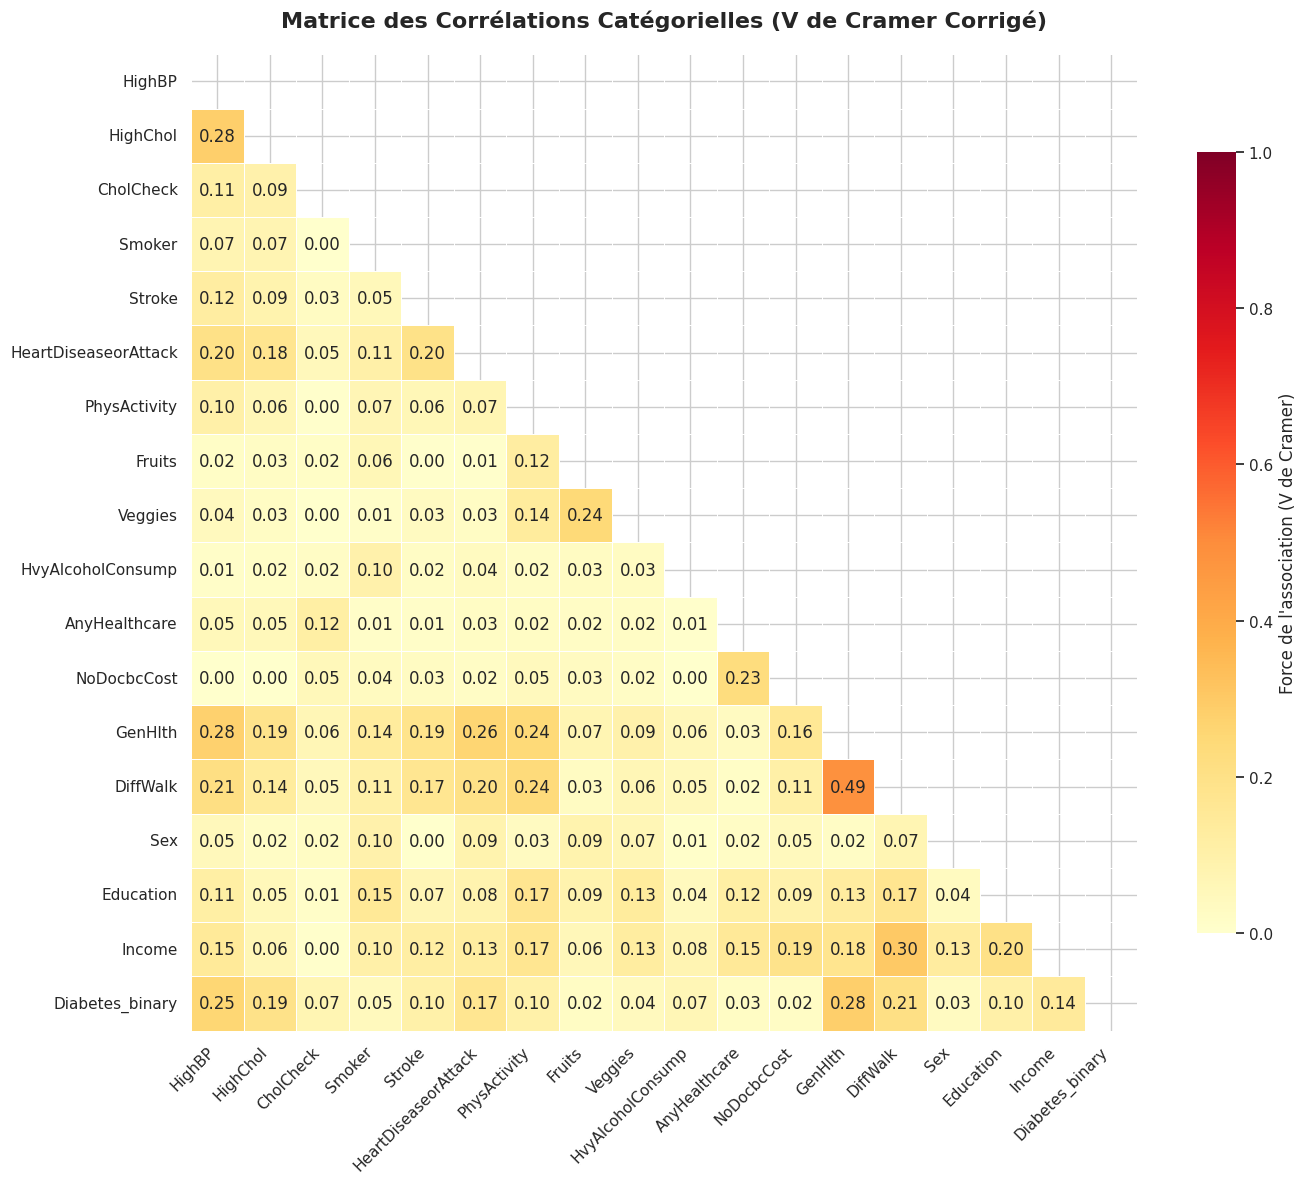

In [ ]:

import scipy.stats as ss

def cramers_v(x, y):
    """
    Calcule le V de Cramer corrigé pour contrer le biais d'estimation.
    Prend en entrée deux séries Pandas (variables catégorielles).
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Correction du biais
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    # Sécurité pour éviter la division par zéro
    denominateur = min((kcorr-1), (rcorr-1))
    if denominateur == 0:
        return 0.0

    return np.sqrt(phi2corr / denominateur)

print("Calcul de la matrice de corrélation en cours...")

# On crée deja  un dataframe df_pour_acm qui contient les bonnes colonnes et qui sera utilisé pour l'acm
colonnes_pour_acm = categorielles + [cible]
df_pour_acm = data_cleaned_copie[colonnes_pour_acm].copy()

colonnes = df_pour_acm.columns
matrice_cramer = pd.DataFrame(index=colonnes, columns=colonnes)

# Remplissage de la matrice avec les scores
for col1 in colonnes:
    for col2 in colonnes:
        # Optimisation : la matrice est symétrique, la diagonale vaut 1
        if col1 == col2:
            matrice_cramer.loc[col1, col2] = 1.0
        else:
            matrice_cramer.loc[col1, col2] = cramers_v(df_pour_acm[col1], df_pour_acm[col2])

# Conversion en float pour Seaborn
matrice_cramer = matrice_cramer.astype(float)

# --- VISUALISATION ---
plt.figure(figsize=(14, 12))

# Création d'un masque pour ne cacher la partie supérieure (optionnel mais plus propre)
mask = np.triu(np.ones_like(matrice_cramer, dtype=bool))

sns.heatmap(
    matrice_cramer,
    annot=True,          # Affiche les valeurs
    mask=mask,           # Cache le triangle supérieur redondant
    cmap='YlOrRd',       # Palette allant du jaune (faible) au rouge (fort)
    vmin=0, vmax=1,      # L'échelle est strictement entre 0 et 1
    fmt=".2f",           # 2 chiffres après la virgule
    linewidths=0.5,
    cbar_kws={"shrink": .8, "label": "Force de l'association (V de Cramer)"}
)

plt.title("Matrice des Corrélations Catégorielles (V de Cramer Corrigé)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

En observant cette matrice de correlation de Cramer, nous allons supprimer les variables 'Fruits',
    'NoDocbcCost', 'Sex', 'AnyHealthcare', 'Veggies' car leurs coefficients de Cramer sont très faible (inférieur à O.05)

### **Suppressions de variables**

In [ ]:
# Suppression des variables socio-économiques pour des raisons éthiques et métiers
data_cleaned_final= data_cleaned.drop(columns=['Fruits', 'MentHlth',
    'NoDocbcCost', 'Sex', 'AnyHealthcare', 'Veggies'])

print(f"Nouvelles dimensions du dataset : {data_cleaned_final.shape}")
data_cleaned_final

Nouvelles dimensions du dataset : (229474, 16)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,GenHlth,PhysHlth,DiffWalk,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,5.0,15.0,1.0,62,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,52,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,0.0,5.0,30.0,1.0,62,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,72,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,72,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,0.0,3.0,5.0,0.0,42,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0,72,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,27,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,52,5.0,1.0


### **Séparation des données**

Nous allons d'abord séparer la variable cicle des autres variables, ensuite effectuer un triple découpage.
Le triple découpage stratifié (70% Train / 15% Validation / 15% Test) : Cette structure est indispensable en Deep Learning. Le jeu d'entraînement permet au modèle d'apprendre, la validation permet d'ajuster les poids à chaque "époque" (epoch) tout en surveillant le surapprentissage (overfitting), et le test garantit une évaluation finale totalement neutre. La stratification assure que la prévalence réelle du diabète est respectée dans chaque sous-groupe.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("--- Séparation des données (70% Train / 15% Val / 15% Test) ---")

# 1. Séparation X et y
X = data_cleaned_final.drop(columns=['Diabetes_binary'])
y = data_cleaned_final['Diabetes_binary']

# 2. Premier split : On isole les 15% de Test (Il reste 85% dans 'temp')
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,       # Maintient le ratio de diabétiques
    random_state=42
)

# 3. Deuxième split : On coupe les 85% restants pour avoir 70% Train et 15% Val
# La proportion est de 15/85 pour la validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=(15/85),
    stratify=y_temp,  # Maintient le ratio de diabétiques
    random_state=42
)

print(f"Dimensions Train : {X_train.shape[0]} patients")
print(f"Dimensions Val   : {X_val.shape[0]} patients")
print(f"Dimensions Test  : {X_test.shape[0]} patients\n")

# 4. Calcul intelligent des poids pour le réseau de neurones (La meilleure alternative à SMOTE)
poids_calcules = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: poids_calcules[0], 1: poids_calcules[1]}

print(f"Poids attribués par le modèle :")
print(f"- Poids classe 0 (Sains)       : {class_weights[0]:.2f}")
print(f"- Poids classe 1 (Diabétiques) : {class_weights[1]:.2f} (Erreur lourdement pénalisée !)")

--- Séparation des données (70% Train / 15% Val / 15% Test) ---
Dimensions Train : 160631 patients
Dimensions Val   : 34421 patients
Dimensions Test  : 34422 patients

Poids attribués par le modèle :
- Poids classe 0 (Sains)       : 0.59
- Poids classe 1 (Diabétiques) : 3.27 (Erreur lourdement pénalisée !)


L'attribution des Poids de Classes (Class Weights) : Face au déséquilibre naturel de la maladie (minorité de patients diabétiques), nous avons écarté la génération de données synthétiques qui risque de créer des profils cliniques aberrants sur des variables catégorielles. Nous avons opté pour un rééquilibrage mathématique via la fonction de coût : l'algorithme est lourdement pénalisé lors de la rétropropagation du gradient s'il se trompe sur un patient malade, le forçant à identifier les signaux faibles sans altérer la réalité des données.

### Pipeline de transformation des données

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

print("--- Création et application du Pipeline de Prétraitement ---")

# 1. Identification stricte des colonnes
vraies_continues = ['BMI', 'PhysHlth', 'Age']
# Toutes les autres colonnes de X sont catégorielles
categorielles = [col for col in X_train.columns if col not in vraies_continues]

# 2. Définition des "recettes" (Pipelines) pour chaque type de donnée
numeric_transformer = Pipeline(steps=[
    ('robust_scaler', RobustScaler()) # Insensible aux outliers comme le BMI extrême
])

categorical_transformer = Pipeline(steps=[
    # drop='if_binary' évite la malédiction de la dimensionnalité en ne créant pas de colonnes doublons
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False))
])

# 3. Assemblage dans le ColumnTransformer (Le chef d'orchestre)
preprocesseur = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, vraies_continues),
        ('cat', categorical_transformer, categorielles)
    ],
    remainder='passthrough'
)

# 4. L'application stricte (SANS FUITE DE DONNÉES)
# On FIT (apprend les médianes et catégories) uniquement sur le TRAIN
X_train_scaled = preprocesseur.fit_transform(X_train)

# On TRANSFORM (applique bêtement les règles apprises) sur la Validation et le Test
X_val_scaled = preprocesseur.transform(X_val)
X_test_scaled = preprocesseur.transform(X_test)

print("Les tenseurs sont parfaitement prétraités, robustes aux outliers")

--- Création et application du Pipeline de Prétraitement ---
Les tenseurs sont parfaitement prétraités, robustes aux outliers


### **Le Pipeline de Transformation**


Pour transformer nos données cliniques en tenseurs lisibles par l'IA sans créer de "fuite de données" (Data Leakage), un ColumnTransformer strict a été mis en place :

Le choix du RobustScaler : Contrairement au StandardScaler classique basé sur la moyenne, le RobustScaler utilise la médiane et l'écart interquartile. C'est un choix optimal pour nos variables quantitatives, car il neutralise l'impact des valeurs cliniques extrêmes (outliers) identifiées lors de l'exploration (comme des IMC très élevés), évitant ainsi une instabilité des gradients lors de l'apprentissage.

Le OneHotEncoder optimisé : Appliqué aux variables catégorielles avec le paramètre drop='if_binary', il convertit les modalités en format binaire de manière stricte, évitant la redondance d'information (colinéarité parfaite) et réduisant la dimensionnalité de la matrice d'entrée.

### **Reconstitution des fichiers et sauvegarde**

In [ ]:
import pandas as pd

print("--- Sauvegarde des données pré-traitées ---")

# 1. Récupération des noms exacts des colonnes après le passage dans le Pipeline
noms_colonnes = preprocesseur.get_feature_names_out()

# Optionnel mais très recommandé : Nettoyage des noms
# (Scikit-Learn ajoute souvent des préfixes moches comme 'num__' ou 'cat__', on les enlève)
noms_colonnes_propres = [nom.split('__')[-1] for nom in noms_colonnes]

# 2. Reconversion des matrices NumPy en DataFrames Pandas
# L'argument "index" permet de s'assurer qu'on garde le même ordre pour recoller la cible juste après
X_train_df = pd.DataFrame(X_train_scaled, columns=noms_colonnes_propres, index=X_train.index)
X_val_df = pd.DataFrame(X_val_scaled, columns=noms_colonnes_propres, index=X_val.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=noms_colonnes_propres, index=X_test.index)


# 4. Exportation en CSV (index=False permet de ne pas sauvegarder l'index numérique inutile)
X_train_df.to_csv('diabete_train_pretraite.csv', index=False)
X_val_df.to_csv('diabete_val_pretraite.csv', index=False)
X_test_df.to_csv('diabete_test_pretraite.csv', index=False)

print("Succès ! Les 3 fichiers (Train, Validation, Test) sont sauvegardés dans le dossier courant.")

--- Sauvegarde des données pré-traitées ---
Succès ! Les 3 fichiers (Train, Validation, Test) sont sauvegardés dans le dossier courant.


La conversion des matrices NumPy générées par le pipeline en DataFrames Pandas (avec récupération automatisée des noms de caractéristiques), suivie de leur exportation en fichiers .csv, fige la base de données.

Cette étape garantit la reproductibilité absolue des expérimentations futures, sécurise les données contre toute modification accidentelle, et permet de dissocier purement la phase de "Data Engineering" de la phase de "Modélisation AI", économisant ainsi du temps de calcul.

### **Aperçu des données pré-traitées**

In [ ]:
print("\n fichier d' Entrainement:")
data__1 = pd.read_csv("diabete_train_pretraite.csv")
display(data__1)
print("\n fichier de Test:")
data__2 = pd.read_csv("diabete_test_pretraite.csv")
display(data__2)
data__3 = pd.read_csv("diabete_val_pretraite.csv")
print("\n fichier de Validation:")
display(data__3)


 fichier d' Entrainement:


,BMI,PhysHlth,Age,HighBP_1.0,HighChol_1.0,CholCheck_1.0,Smoker_1.0,Stroke_1.0,HeartDiseaseorAttack_1.0,PhysActivity_1.0,...,Education_5.0,Education_6.0,Income_1.0,Income_2.0,Income_3.0,Income_4.0,Income_5.0,Income_6.0,Income_7.0,Income_8.0
0,-1.000,7.50,-0.50,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.625,1.25,1.00,1.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.000,0.00,1.25,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.375,1.75,0.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.250,0.00,-0.25,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160626,0.625,1.00,1.00,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
160627,-0.500,1.75,0.00,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
160628,1.000,0.00,-1.80,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
160629,0.000,0.00,1.00,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



 fichier de Test:


,BMI,PhysHlth,Age,HighBP_1.0,HighChol_1.0,CholCheck_1.0,Smoker_1.0,Stroke_1.0,HeartDiseaseorAttack_1.0,PhysActivity_1.0,...,Education_5.0,Education_6.0,Income_1.0,Income_2.0,Income_3.0,Income_4.0,Income_5.0,Income_6.0,Income_7.0,Income_8.0
0,-0.500,0.00,0.25,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.000,0.00,-0.25,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.625,0.00,-0.25,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2.500,0.00,0.00,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.875,7.50,0.50,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34417,-0.500,0.25,0.75,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
34418,1.500,0.00,1.25,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34419,-0.250,0.00,-0.50,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34420,0.750,0.00,-1.00,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0



 fichier de Validation:


,BMI,PhysHlth,Age,HighBP_1.0,HighChol_1.0,CholCheck_1.0,Smoker_1.0,Stroke_1.0,HeartDiseaseorAttack_1.0,PhysActivity_1.0,...,Education_5.0,Education_6.0,Income_1.0,Income_2.0,Income_3.0,Income_4.0,Income_5.0,Income_6.0,Income_7.0,Income_8.0
0,1.000,1.50,1.00,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.625,0.00,-0.25,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.500,0.00,0.50,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.000,0.00,-0.25,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.250,0.00,-0.25,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34416,1.250,0.75,1.00,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34417,0.250,0.00,-0.25,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
34418,0.000,0.00,0.75,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
34419,0.625,0.50,0.00,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
